In [2]:
import pandas as pd
import numpy as np

In [3]:
df= pd.read_csv("../data/archive/combine.csv", low_memory=False)
df.columns= df.columns.str.strip()
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [4]:
df.shape

(2214469, 79)

In [5]:
df['Label'] = df['Label'].str.strip().str.upper()

In [6]:
df['Label'].value_counts()

Label
BENIGN              1672837
DOS HULK             231073
PORTSCAN             158930
DDOS                 128027
DOS GOLDENEYE         10293
DOS SLOWLORIS          5796
DOS SLOWHTTPTEST       5499
BOT                    1966
INFILTRATION             36
HEARTBLEED               11
Name: count, dtype: int64

In [7]:
df['Label']=df['Label'].replace({
    'DOS HULK':'DOS',
    'DOS GOLDENEYE':'DOS',
    'DOS SLOWLORIS':'DOS',
    'DOS SLOWHTTPTEST':'DOS'
})

In [8]:
df = df[df['Label'].isin(['BENIGN','DOS','PORTSCAN','DDOS'])]

In [9]:
print("Class distribution after label mapping and filtering:",df['Label'].value_counts())

Class distribution after label mapping and filtering: Label
BENIGN      1672837
DOS          252661
PORTSCAN     158930
DDOS         128027
Name: count, dtype: int64


In [10]:
print("Shape before cleaning:", df.shape)

Shape before cleaning: (2212455, 79)


In [11]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (1939657, 79)


In [12]:
X = df.drop('Label', axis=1)
y = df['Label']

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,  
    random_state=42,
    stratify=y
)

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,   
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)


In [15]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=6))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9986217515784553
              precision    recall  f1-score   support

      BENIGN   0.999138  0.999144  0.999141    458161
        DDOS   0.999922  0.999688  0.999805     38405
         DOS   0.998158  0.997523  0.997840     58124
    PORTSCAN   0.989101  0.990665  0.989882     27208

    accuracy                       0.998622    581898
   macro avg   0.996580  0.996755  0.996667    581898
weighted avg   0.998622  0.998622  0.998622    581898

[[457769      3     93    296]
 [     9  38393      3      0]
 [   143      0  57980      1]
 [   243      0     11  26954]]


In [18]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
8,Fwd Packet Length Mean,0.074152
63,Subflow Fwd Bytes,0.067098
4,Total Length of Fwd Packets,0.052250
6,Fwd Packet Length Max,0.051157
53,Avg Fwd Segment Size,0.038819
67,Init_Win_bytes_backward,0.037449
37,Bwd Packets/s,0.033395
40,Packet Length Mean,0.032869
18,Flow IAT Max,0.031708
23,Fwd IAT Max,0.031018


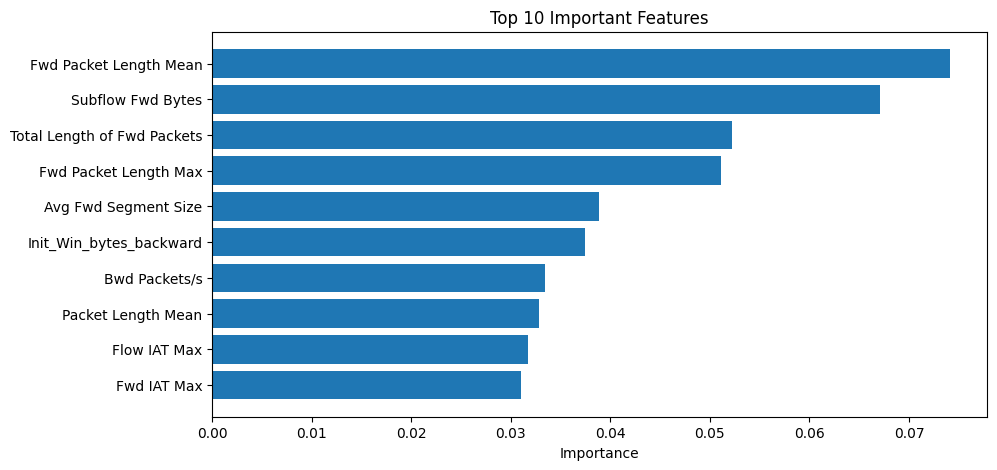

In [19]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [20]:
import joblib

joblib.dump(model, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']

In [21]:
test_data = X_test.sample(100, random_state=42)
test_data.to_csv("../data/sample_test.csv", index=False)

In [22]:
print(X.shape)
print(X.columns.tolist())

(1939657, 78)
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', '